#**Introduction**

Unsupervised learning means training on data that has no labels — the algorithm isn't told the "right answer," it just finds patterns or structure in the data on its own. This is different from supervised learning, where you have input-output pairs to learn from.

Clustering is one of the most common unsupervised tasks:

- Grouping similar data points together.
- K-Means is the most popular clustering algorithm because of its simplicity and efficiency.

- K-Means is an unsupervised machine learning algorithm used to group similar data points into clusters based on distance.
- K-Means works best when data is **well-separated**, **structured**, and **circular in shape**.
- It is commonly used for customer segmentation, pattern recognition, and data grouping.

**Steps of K-Means Algorithm**:

1. Choose K — decide the number of clusters you want.
2. Initialize centroids — randomly pick K points as initial cluster centers.
3. Assign step — assign each data point to the nearest centroid (usually using Euclidean distance).
4. Update step — recalculate each centroid as the mean of all points assigned to that cluster.
5. Repeat steps 3 and 4 until centroids stop moving (convergence) or a max number of iterations is reached.

##**Import Libraries**

In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##**Create Dummy Dataset**

This creates synthetic clustered data.

Parameters:

- n_samples = 700 → total points
- centers = 2 → 2 clusters
- cluster_std = 1 → spread
- random_state → reproducible result

In [ ]:
from sklearn.datasets import make_blobs

In [ ]:
x, y = make_blobs(n_samples=700, centers=2, cluster_std=1, random_state=42)

In [ ]:
x

array([[ 4.77341974,  1.82069985],
       [-1.68378127,  9.82779576],
       [ 6.03008639,  2.53097999],
       ...,
       [ 6.72825354,  1.83358006],
       [-2.43939554,  8.62897253],
       [-2.76878897,  7.51114318]])

##**Convert to DataFrame**

In [ ]:
df = pd.DataFrame(x, columns = ["x1","x2"])

In [ ]:
df

,x1,x2
0,4.773420,1.820700
1,-1.683781,9.827796
2,6.030086,2.530980
3,-2.778604,9.731828
4,-5.160167,10.105793
...,...,...
695,6.305353,2.987540
696,4.873665,0.417274
697,6.728254,1.833580
698,-2.439396,8.628973


##**Feature Scaling**

- KMeans uses distance
- Features must be same scale

In [ ]:
from sklearn.preprocessing import StandardScaler

scler = StandardScaler()
X_scaled = scler.fit_transform(df)

In [ ]:
X_scaled

array([[ 0.97689919, -1.020064  ],
       [-0.74095081,  1.18581838],
       [ 1.31121816, -0.82438826],
       ...,
       [ 1.49695598, -1.01651562],
       [-0.94197165,  0.85555344],
       [-1.02960227,  0.54760158]])

##**Find Best K (Elbow Method)**

This calculates inertia for each K

- Inertia = distance inside cluster
- Lower inertia = better clustering
- High inertia = bad clustering

In [ ]:
inertia = []
k_range = range(1,11)

In [ ]:
from sklearn.cluster import KMeans
for k in k_range:
    kmeans  = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [ ]:
inertia

[1400.000000000001,
 100.06936893999085,
 83.63960676215606,
 73.24110558689576,
 54.28315957019537,
 44.62939103276432,
 39.834628434510485,
 35.60785757260922,
 31.423015432454044,
 29.877140329856964]

##**Plot Elbow Graph**

We choose K where elbow occurs

Notebook selects:

k = 2

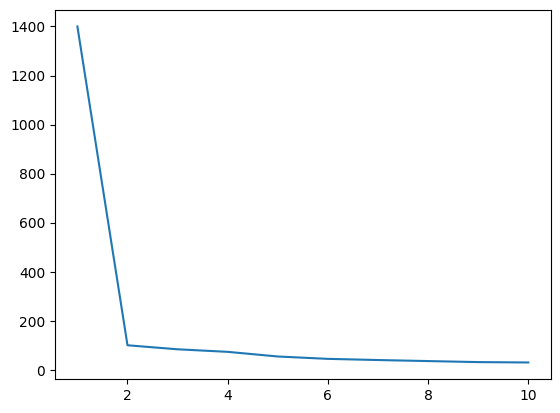

In [ ]:
# Graph Plotting
plt.plot(k_range, inertia)
plt.show()

##**Apply Final KMeans**

- fits model
- assigns cluster labels

In [ ]:
final_modal = KMeans(n_clusters = 2,random_state = 42)
final_modal.fit(X_scaled)

KMeans(n_clusters=2, random_state=42)

In [ ]:
cluster = final_modal.fit_predict(X_scaled)

##**Add Cluster to Data**

In [ ]:
df["cluster"] = cluster

In [ ]:
df

,x1,x2,cluster
0,4.773420,1.820700,0
1,-1.683781,9.827796,1
2,6.030086,2.530980,0
3,-2.778604,9.731828,1
4,-5.160167,10.105793,1
...,...,...,...
695,6.305353,2.987540,0
696,4.873665,0.417274,0
697,6.728254,1.833580,0
698,-2.439396,8.628973,1


##**Visualize Clusters**

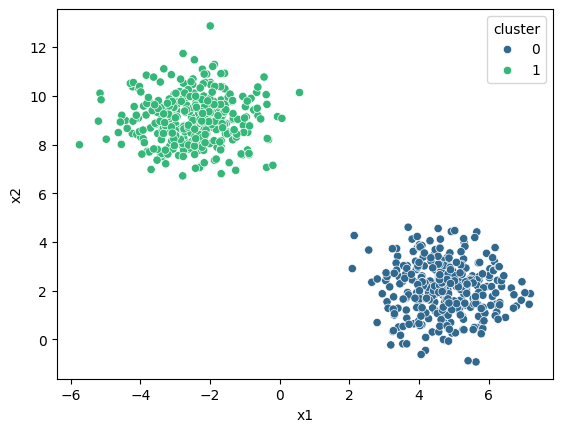

In [ ]:
# Scatterplot - find the relationship between two numerical values
sns.scatterplot(x=df["x1"], y = df["x2"], hue=df["cluster"],palette = 'viridis')
plt.show()

##**Conclusion**
1. K-Means clustering grouped similar data points into two clear clusters based on distance.
2. The Elbow Method helped identify the optimal number of clusters (K = 2).
3. Feature scaling improved clustering performance by standardizing data values.
4. Cluster visualization showed well-separated and homogeneous groups.
5. K-Means worked effectively for circular and evenly distributed data points.

##**DBSCAN**

- DBSCAN stands for Density-Based Spatial Clustering of Applications with Noise.

- It creates clusters based on the density (closeness) of data points and automatically detects outliers (noise).

In [ ]:
# import pre-dataset
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

In [ ]:
X, y = make_moons(n_samples = 500, noise = 0.05, random_state = 42)

In [ ]:
# create a dataframe(rows and columns)
df_db = pd.DataFrame(X, columns = ["x1", "x2"])

In [ ]:
df_db.head()

,x1,x2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [ ]:
db_scale = StandardScaler().fit_transform(df_db)

In [ ]:
# Apply K_Means clustering

kmeans = KMeans(n_clusters = 2, random_state = 42)
labelkmeans = kmeans.fit_predict(db_scale)

In [ ]:
df_db["K_label"] = labelkmeans

In [ ]:
df_db.head()

,x1,x2,K_label
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


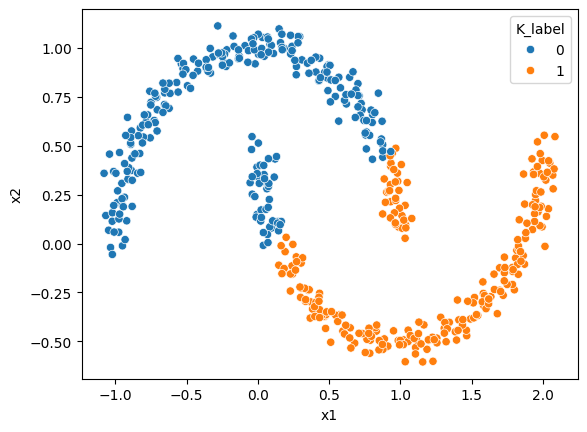

In [ ]:
# Scatter Plotting
sns.scatterplot(x="x1", y = "x2", hue="K_label",data = df_db)
plt.show()

The algorithm maps out regions of high density separated by areas of low density using two primary parameters:

1. **ε (Eps)**: The maximum radius of the neighborhood around a data point.

2. **MinPts**: The minimum number of points required to form a dense region (or cluster) within that ε radius. Minpts is greater than or equal to 3(Minpts >= 3).

In [ ]:
# Apply DBSCAN

dbscan = DBSCAN(eps = 0.2, min_samples = 5)

In [ ]:
dbscan_label = dbscan.fit_predict(db_scale)

In [ ]:
df_db["db_label"] = dbscan_label

In [ ]:
df_db.head()

,x1,x2,K_label,db_label
0,0.830586,-0.447733,1,0
1,0.701678,0.816918,0,1
2,1.022080,-0.492571,1,0
3,-0.316765,0.953438,0,1
4,0.293226,1.057185,0,1


In [ ]:
# count numbers of db_label
df_db.db_label.value_counts()

,count
db_label,
0,250
1,250


Every point is classified into one of three categories:
1. Core Point: A point that has at least MinPts neighbors within its ε distance.
2. Border Point: A point that has fewer than MinPts neighbors within ε, but falls within the neighborhood of a core point.
3. Noise(Outlier): A point that is neither a core point nor a border point.

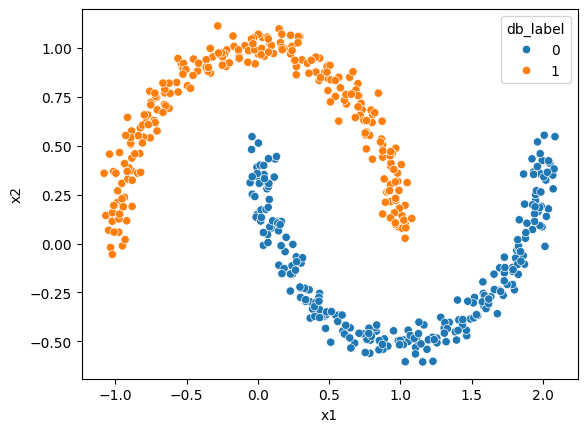

In [ ]:
# Scatter Plot

sns.scatterplot(x = "x1", y = "x2", hue = "db_label", data = df_db)
plt.show()

##**Conclusion:**
1. It correctly found 2 clusters with 250 points in each cluster, matching the actual moon shapes in the data.

2. DBSCAN found 0 noise points, meaning every point fit nicely into a cluster (0% outliers).

3. This shows DBSCAN is better than K-Means when clusters are curved or unevenly shaped, since it groups by density instead of distance.

4. In short K-Means = good for round/circular clusters, DBSCAN = good for irregular/curved clusters and can also detect outliers automatically.